In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
train_df = pd.read_csv('/content/drive/MyDrive/hindi-movie-reviews-dataset/train.csv')
valid_df = pd.read_csv('/content/drive/MyDrive/hindi-movie-reviews-dataset/valid.csv')

In [ ]:
print("Train Shape:", train_df.shape)
print("Validation Shape:", valid_df.shape)

Train Shape: (718, 2)
Validation Shape: (180, 2)


In [ ]:
train_df.head()

,text,experience
0,चंद्रमोहन शर्मा को-प्रड्यूसर और लीड ऐक्टर अक्ष...,2
1,अगर आप इस फिल्म को देखने जा रहे हैं तो सबसे पह...,0
2,बॉलीवुड वाले चोरी-छिपे हॉलीवुड फिल्मों से कहान...,2
3,"बैनर :\nसंजय दत्त प्रोडक्शन्स प्रा.लि., रुपाली...",0
4,1959 में घटित चर्चित नानावटी कांड में एक क्राइ...,1


In [ ]:
print("Train Columns:", train_df.columns.tolist())
print("Validation Columns:", valid_df.columns.tolist())

Train Columns: ['text', 'experience']
Validation Columns: ['text', 'experience']


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 718 entries, 0 to 717
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        718 non-null    object
 1   experience  718 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 11.3+ KB


In [ ]:
train_df.isnull().sum()

,0
text,0
experience,0


In [ ]:
valid_df.isnull().sum()

,0
text,0
experience,0


In [ ]:
print("Train Duplicates:", train_df.duplicated().sum())
print("Validation Duplicates:", valid_df.duplicated().sum())

Train Duplicates: 0
Validation Duplicates: 0


In [ ]:
train_df['experience'].value_counts()

,count
experience,
2,273
0,240
1,205


In [ ]:
valid_df['experience'].value_counts()

,count
experience,
1,65
2,62
0,53


In [ ]:
train_df['text'].head(10)

,text
0,चंद्रमोहन शर्मा को-प्रड्यूसर और लीड ऐक्टर अक्ष...
1,अगर आप इस फिल्म को देखने जा रहे हैं तो सबसे पह...
2,बॉलीवुड वाले चोरी-छिपे हॉलीवुड फिल्मों से कहान...
3,"बैनर :\nसंजय दत्त प्रोडक्शन्स प्रा.लि., रुपाली..."
4,1959 में घटित चर्चित नानावटी कांड में एक क्राइ...
5,बैनर ‍:\nमिलेनियम फिल्म्स\n\nनिर्देशक :\nपेट्र...
6,"\nचश्मे बद्दूर (1981) एक क्लासिक मूवी है, जिसे..."
7,\n\nदिल्ली की एक पांच सितारा होटल में डैन (वरु...
8,"\nहसीना एक घरेलू लड़की थी, लेकिन भाई के भाग जा..."
9,जैसा कि फिल्म के नाम से ही जाहिर है कि हर बार ...


In [ ]:
train_df['text'].str.len().describe()

,text
count,718.000000
mean,3387.614206
std,904.072964
min,1.000000
25%,2787.500000
50%,3304.500000
75%,3951.000000
max,6871.000000


In [ ]:
train_df[train_df['text'].str.len() < 20]

,text,experience
238,\n,1


In [ ]:
train_df['experience'].value_counts(normalize=True) * 100

,proportion
experience,
2,38.022284
0,33.426184
1,28.551532


In [ ]:
# Rows before cleaning
print("Train rows before cleaning:", len(train_df))
print("Validation rows before cleaning:", len(valid_df))

# Remove reviews that are empty or contain only whitespace/newline characters
train_df = train_df[train_df['text'].str.strip().astype(bool)]
valid_df = valid_df[valid_df['text'].str.strip().astype(bool)]

# Reset index
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

# Rows after cleaning
print("Train rows after cleaning:", len(train_df))
print("Validation rows after cleaning:", len(valid_df))

Train rows before cleaning: 718
Validation rows before cleaning: 180
Train rows after cleaning: 717
Validation rows after cleaning: 180


In [ ]:
import re

def clean_text(text):
    # Remove newline characters
    text = text.replace('\n', ' ')

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Keep only Hindi letters, English letters and spaces
    text = re.sub(r'[^\u0900-\u097Fa-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [ ]:
train_df['clean_text'] = train_df['text'].apply(clean_text)
valid_df['clean_text'] = valid_df['text'].apply(clean_text)

In [ ]:
for i in range(3):
    print("="*100)
    print("ORIGINAL:")
    print(train_df['text'].iloc[i][:500])

    print("\nCLEANED:")
    print(train_df['clean_text'].iloc[i][:500])
    print()

ORIGINAL:
चंद्रमोहन शर्मा को-प्रड्यूसर और लीड ऐक्टर अक्षय कुमार की मानें तो उनकी नई फिल्म एयरलिफ्ट की कहानी और किरदार बिल्कुल सच्चे हैं। पहले खाड़ी युद्ध को कवर करने वाले एक सीनियर रिपोर्टर और उस वक्त एयर इंडिया में उच्च पद पर रहे एक अफसर इस कहानी को सच से परे मानते हैं। हालांकि, स्क्रीन पर आप जो कुछ भी देखेंगे वह सब सच के बेहद करीब है। बॉलिवुड की खबरें अपने फेसबुक पर पाना हो तो लाइक करें Nbt Movies फिल्म की कहानी चार अहम किरदारों के इर्द-गिर्द घूमती है। इन चारों को मिलाकर एक लीड किरदार स्क्रीन पर उतारा ग

CLEANED:
चंद्रमोहन शर्मा को प्रड्यूसर और लीड ऐक्टर अक्षय कुमार की मानें तो उनकी नई फिल्म एयरलिफ्ट की कहानी और किरदार बिल्कुल सच्चे हैं। पहले खाड़ी युद्ध को कवर करने वाले एक सीनियर रिपोर्टर और उस वक्त एयर इंडिया में उच्च पद पर रहे एक अफसर इस कहानी को सच से परे मानते हैं। हालांकि स्क्रीन पर आप जो कुछ भी देखेंगे वह सब सच के बेहद करीब है। बॉलिवुड की खबरें अपने फेसबुक पर पाना हो तो लाइक करें Nbt Movies फिल्म की कहानी चार अहम किरदारों के इर्द गिर्द घूमती है। इन चारों को मिलाकर एक लीड किरदा

In [ ]:
hindi_stopwords = {
    'है','हैं','था','थे','थी','और','का','की','के',
    'में','से','को','पर','तो','यह','वह','भी','ही',
    'एक','कि','जो','कर','करने','किया','लिए','अपनी',
    'अपने','अगर','लेकिन','या','तक','जब','जहां','जहाँ'
}

In [ ]:
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in hindi_stopwords]
    return " ".join(filtered_words)

In [ ]:
train_df['processed_text'] = train_df['clean_text'].apply(remove_stopwords)
valid_df['processed_text'] = valid_df['clean_text'].apply(remove_stopwords)

In [ ]:
for i in range(2):
    print("="*100)
    print("CLEANED:")
    print(train_df['clean_text'].iloc[i][:300])

    print("\nPROCESSED:")
    print(train_df['processed_text'].iloc[i][:300])
    print()

CLEANED:
चंद्रमोहन शर्मा को प्रड्यूसर और लीड ऐक्टर अक्षय कुमार की मानें तो उनकी नई फिल्म एयरलिफ्ट की कहानी और किरदार बिल्कुल सच्चे हैं। पहले खाड़ी युद्ध को कवर करने वाले एक सीनियर रिपोर्टर और उस वक्त एयर इंडिया में उच्च पद पर रहे एक अफसर इस कहानी को सच से परे मानते हैं। हालांकि स्क्रीन पर आप जो कुछ भी देखेंग

PROCESSED:
चंद्रमोहन शर्मा प्रड्यूसर लीड ऐक्टर अक्षय कुमार मानें उनकी नई फिल्म एयरलिफ्ट कहानी किरदार बिल्कुल सच्चे हैं। पहले खाड़ी युद्ध कवर वाले सीनियर रिपोर्टर उस वक्त एयर इंडिया उच्च पद रहे अफसर इस कहानी सच परे मानते हैं। हालांकि स्क्रीन आप कुछ देखेंगे सब सच बेहद करीब है। बॉलिवुड खबरें फेसबुक पाना हो लाइक क

CLEANED:
अगर आप इस फिल्म को देखने जा रहे हैं तो सबसे पहले तो आप यह जान लीजिए कि बेशक इस फिल्म के साथ प्रडूयसर कुमार मंगत डायरेक्टर अश्विनी धीर के नाम के साथ परेश रावल का नाम भी जुड़ा हो लेकिन कुछ साल पहले आई फिल्म अतिथि तुम कब जाओगे से इस फिल्म का कुछ लेना देना नहीं है। यूं तो इस फिल्म के क्लाइमैक्स में आपको

PROCESSED:
आप इस फिल्म देखने जा रहे सबसे पहले आप जान लीजिए बेशक इ

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),

)

X_train = tfidf.fit_transform(train_df['processed_text'])
X_valid = tfidf.transform(valid_df['processed_text'])

y_train = train_df['experience']
y_valid = valid_df['experience']

In [ ]:
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)

X_train shape: (717, 5000)
X_valid shape: (180, 5000)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_valid)

In [ ]:
print("Naive Bayes Accuracy:", accuracy_score(y_valid, nb_pred))

Naive Bayes Accuracy: 0.4388888888888889


In [ ]:
print(classification_report(y_valid, nb_pred))

              precision    recall  f1-score   support

           0       0.61      0.38      0.47        53
           1       1.00      0.05      0.09        65
           2       0.39      0.90      0.54        62

    accuracy                           0.44       180
   macro avg       0.66      0.44      0.37       180
weighted avg       0.67      0.44      0.36       180



In [ ]:
from sklearn.metrics import confusion_matrix

cm_nb = confusion_matrix(y_valid, nb_pred)

print(cm_nb)

[[20  0 33]
 [ 7  3 55]
 [ 6  0 56]]


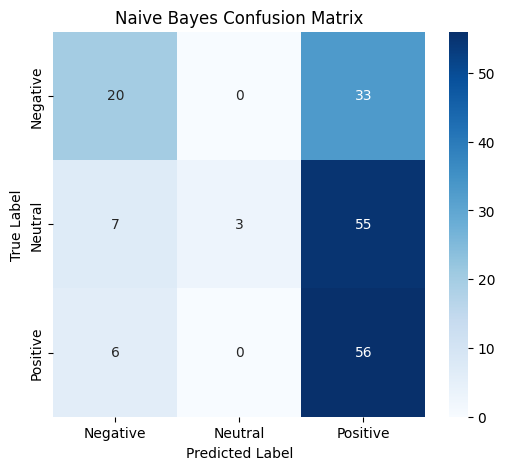

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_valid, nb_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative','Neutral','Positive'],
    yticklabels=['Negative','Neutral','Positive']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Naive Bayes Confusion Matrix')

plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_valid)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_valid, lr_pred))

Logistic Regression Accuracy: 0.6


In [ ]:
print(classification_report(y_valid, lr_pred))

              precision    recall  f1-score   support

           0       0.57      0.53      0.55        53
           1       0.63      0.49      0.55        65
           2       0.60      0.77      0.68        62

    accuracy                           0.60       180
   macro avg       0.60      0.60      0.59       180
weighted avg       0.60      0.60      0.59       180



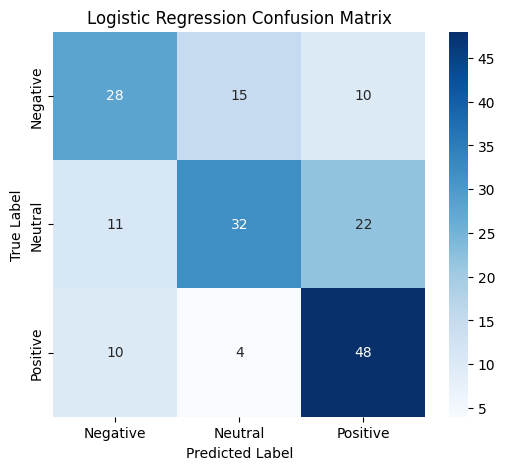

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_valid, lr_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative','Neutral','Positive'],
    yticklabels=['Negative','Neutral','Positive']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [ ]:
from sklearn.svm import LinearSVC

In [ ]:
svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_valid)

In [ ]:
from sklearn.metrics import accuracy_score

print("SVM Accuracy:", accuracy_score(y_valid, svm_pred))

SVM Accuracy: 0.55


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, svm_pred))

              precision    recall  f1-score   support

           0       0.47      0.51      0.49        53
           1       0.56      0.48      0.52        65
           2       0.60      0.66      0.63        62

    accuracy                           0.55       180
   macro avg       0.55      0.55      0.55       180
weighted avg       0.55      0.55      0.55       180



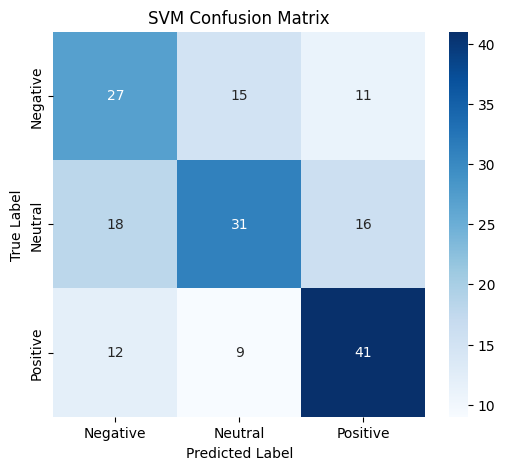

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_valid, svm_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative','Neutral','Positive'],
    yticklabels=['Negative','Neutral','Positive']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM Confusion Matrix")
plt.show()